<a href="https://colab.research.google.com/github/SHIVANSHU-2004/MACHINE-LEARNING/blob/main/DTREE%2011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Age  Registered Vote
0   16           0   No
1   18           1  Yes
2   20           1  Yes
3   22           1  Yes
4   15           0   No
5   30           1  Yes
6   40           1  Yes
7   17           0   No
8   25           1  Yes
9   35           1  Yes

Prediction for Age=19 and Registered=1 : Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


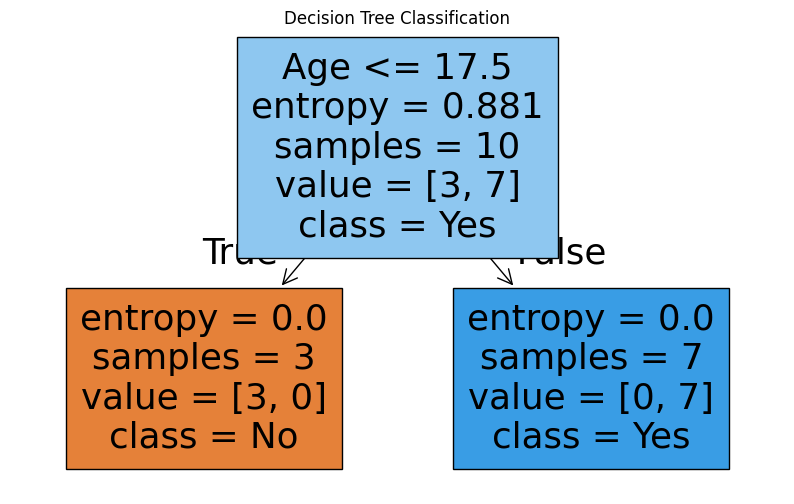

In [ ]:
# Decision Tree Classification Example

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


# Step 1: Create Dataset


data = {
    'Age': [16, 18, 20, 22, 15, 30, 40, 17, 25, 35],
    'Registered': [0, 1, 1, 1, 0, 1, 1, 0, 1, 1],
    'Vote': ['No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

print(df)


# Step 2: Define Features & Target


X = df[['Age', 'Registered']]
y = df['Vote']


# Step 3: Train Decision Tree Model


model = DecisionTreeClassifier(criterion='entropy')

model.fit(X, y)


# Step 4: Predict New Data


prediction = model.predict([[19, 1]])

print("\nPrediction for Age=19 and Registered=1 :", prediction[0])


# Step 5: Visualize Decision Tree


plt.figure(figsize=(10,6))

tree.plot_tree(
    model,
    feature_names=['Age', 'Registered'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.title("Decision Tree Classification")
plt.show()

Dataset:

    Study_Hours  Attendance  Pass
0             1          50     0
1             2          55     0
2             3          60     0
3             4          65     0
4             5          70     1
5             6          75     1
6             7          80     1
7             8          85     1
8             2          58     0
9             5          72     1
10            7          78     1
11            9          90     1
12           10          95     1
13            1          45     0
14            4          68     1

Predicted Values:
[1 1 0]

Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Student will PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


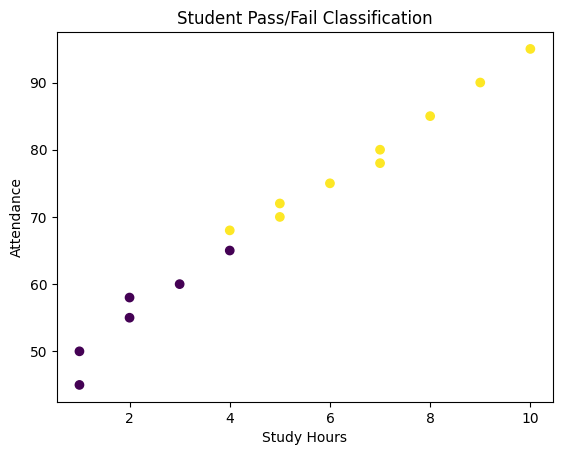

In [ ]:
# Logistic Regression Example,  Predict Student Pass or Fail

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Step 1: Create Dataset


data = {
    'Study_Hours': [1,2,3,4,5,6,7,8,2,5,7,9,10,1,4],
    'Attendance':  [50,55,60,65,70,75,80,85,58,72,78,90,95,45,68],
    'Pass':        [0,0,0,0,1,1,1,1,0,1,1,1,1,0,1]
}

df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

# Step 2: Define Features and Target


X = df[['Study_Hours', 'Attendance']]
y = df['Pass']


# Step 3: Split Dataset


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Step 4: Train Logistic Regression Model


model = LogisticRegression()

model.fit(X_train, y_train)


# Step 5: Prediction


y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)


# Step 6: Accuracy and Evaluation


accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# Step 7: Predict New Student


new_student = [[6, 80]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nStudent will PASS")
else:
    print("\nStudent will FAIL")


# Step 8: Visualization


plt.scatter(df['Study_Hours'], df['Attendance'], c=df['Pass'])

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Student Pass/Fail Classification")

plt.show()

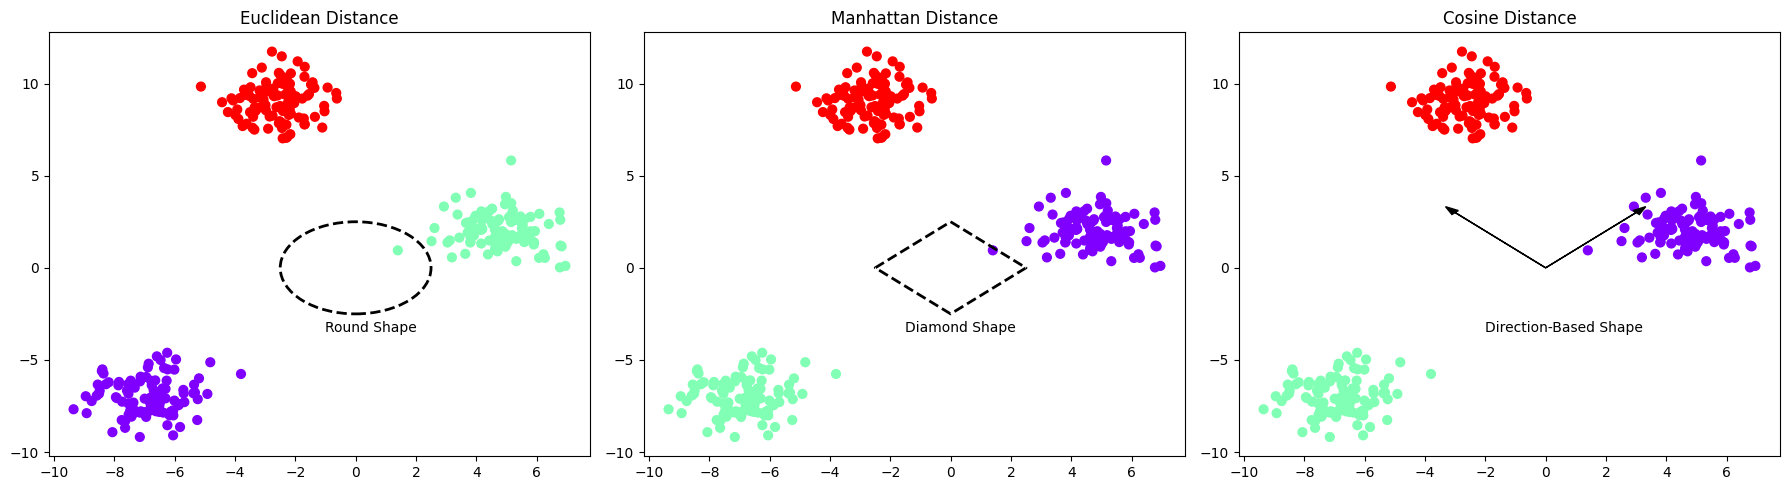

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist

# Generate sample data
X, y = make_blobs(n_samples=300,
                  centers=3,
                  cluster_std=1.0,
                  random_state=42)

# Distance methods
methods = ['euclidean', 'manhattan', 'cosine']

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, methods):

    # Cosine distance handling
    if method == 'cosine':

        distance_matrix = cdist(X, X, metric='cosine')

        model = AgglomerativeClustering(
            n_clusters=3,
            metric='precomputed',
            linkage='average'
        )

        labels = model.fit_predict(distance_matrix)

    else:

        model = AgglomerativeClustering(
            n_clusters=3,
            metric=method,
            linkage='ward' if method == 'euclidean' else 'average'
        )

        labels = model.fit_predict(X)

    # Plot clusters
    scatter = ax.scatter(X[:, 0], X[:, 1],
                         c=labels,
                         cmap='rainbow',
                         s=40)

    ax.set_title(f"{method.capitalize()} Distance")

    # -------- SHOW SHAPES -------- #

    if method == 'euclidean':
        # Circle shape
        circle = plt.Circle((0, 0),
                            2.5,
                            color='black',
                            fill=False,
                            linestyle='--',
                            linewidth=2)
        ax.add_artist(circle)
        ax.text(-1, -3.5, "Round Shape", fontsize=10)

    elif method == 'manhattan':
        # Diamond shape
        diamond_x = [0, 2.5, 0, -2.5, 0]
        diamond_y = [2.5, 0, -2.5, 0, 2.5]
        ax.plot(diamond_x, diamond_y,
                'k--', linewidth=2)
        ax.text(-1.5, -3.5, "Diamond Shape", fontsize=10)

    elif method == 'cosine':
        # Direction arrows
        ax.arrow(0, 0, 3, 3,
                 head_width=0.3,
                 color='black')
        ax.arrow(0, 0, -3, 3,
                 head_width=0.3,
                 color='black')

        ax.text(-2, -3.5,
                "Direction-Based Shape",
                fontsize=10)

plt.tight_layout()
plt.show()

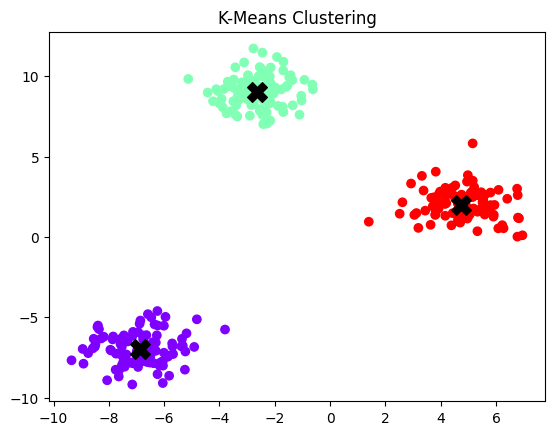

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Create sample data
X, y = make_blobs(n_samples=300,
                  centers=3,
                  random_state=42)

# Apply K-Means
kmeans = KMeans(n_clusters=3)

kmeans.fit(X)

# Plot clusters
plt.scatter(X[:,0], X[:,1],
            c=kmeans.labels_,
            cmap='rainbow')

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            color='black',
            marker='X',
            s=200)

plt.title("K-Means Clustering")
plt.show()

K = 1  Accuracy = 1.0
K = 2  Accuracy = 1.0
K = 3  Accuracy = 1.0
K = 4  Accuracy = 1.0
K = 5  Accuracy = 1.0
K = 6  Accuracy = 1.0
K = 7  Accuracy = 0.9666666666666667
K = 8  Accuracy = 1.0
K = 9  Accuracy = 1.0
K = 10  Accuracy = 1.0
K = 11  Accuracy = 1.0
K = 12  Accuracy = 1.0
K = 13  Accuracy = 1.0
K = 14  Accuracy = 1.0
K = 15  Accuracy = 1.0
K = 16  Accuracy = 1.0
K = 17  Accuracy = 1.0
K = 18  Accuracy = 1.0
K = 19  Accuracy = 1.0
K = 20  Accuracy = 1.0

Optimal K Value = 1


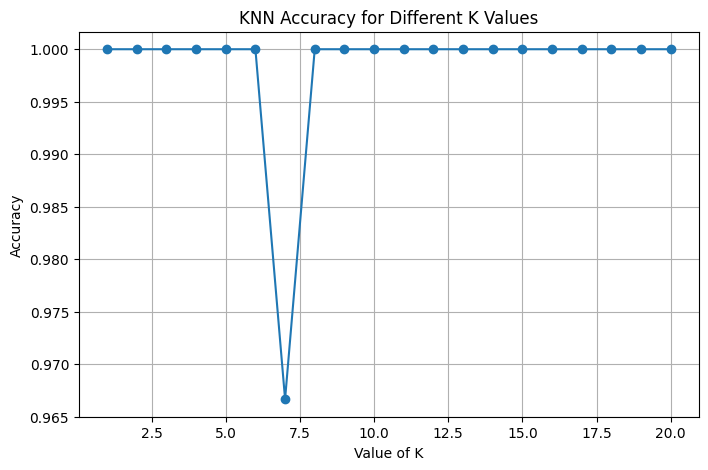

In [ ]:
# Program 17 KNN Classification to Find Optimal K

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

k_values = []
accuracy_values = []

for k in range(1, 21):

    # Create KNN Model
    model = KNeighborsClassifier(n_neighbors=k)

    # Train Model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    # Store Results
    k_values.append(k)
    accuracy_values.append(acc)

    print("K =", k, " Accuracy =", acc)



optimal_k = k_values[accuracy_values.index(max(accuracy_values))]

print("\nOptimal K Value =", optimal_k)


# Step 5: Plot Graph


plt.figure(figsize=(8,5))

plt.plot(k_values, accuracy_values, marker='o')

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("Value of K")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

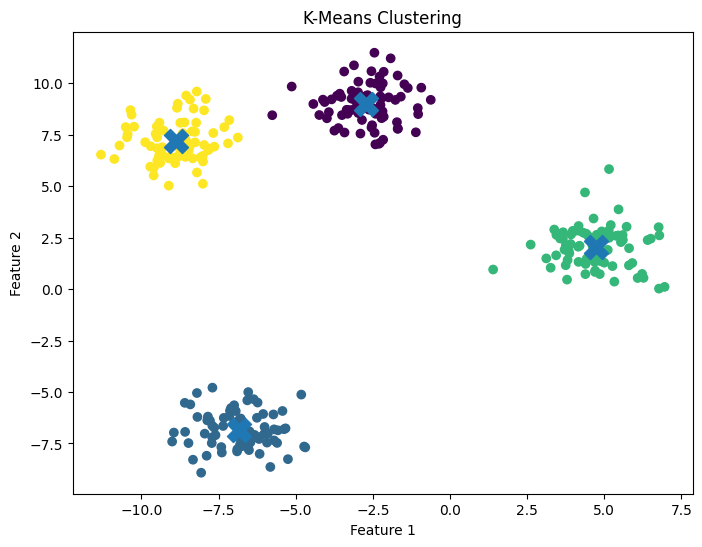

In [ ]:
#Program 18 # K-Means Clustering for Unlabeled Data
# Visualizing Cluster Formation

import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans



X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Train Model and Predict Clusters
y_kmeans = kmeans.fit_predict(X)


plt.figure(figsize=(8,6))

# Plot Data Points
plt.scatter(
    X[:,0],
    X[:,1],
    c=y_kmeans
)

# Plot Cluster Centers
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X'
)

# Labels and Title
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Student data
X = [
    [90, 5, 85],
    [60, 1, 40],
    [80, 4, 75],
    [50, 1, 35]
]

# Results
y = ['Pass', 'Fail', 'Pass', 'Fail']

# Create model
model = RandomForestClassifier()

# Train model
model.fit(X, y)

# Predict new student result
prediction = model.predict([[85, 4, 70]])

print("Predicted Result:", prediction[0])

Predicted Result: Pass


    Study_Hours  Attendance  Pass
0             1          50     0
1             2          55     0
2             3          60     0
3             4          65     0
4             5          70     1
5             6          75     1
6             7          80     1
7             8          85     1
8             2          58     0
9             5          72     1
10            7          78     1
11            9          90     1
12           10          95     1
13            1          45     0
14            4          68     1

Accuracy = 1.0

Student will PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


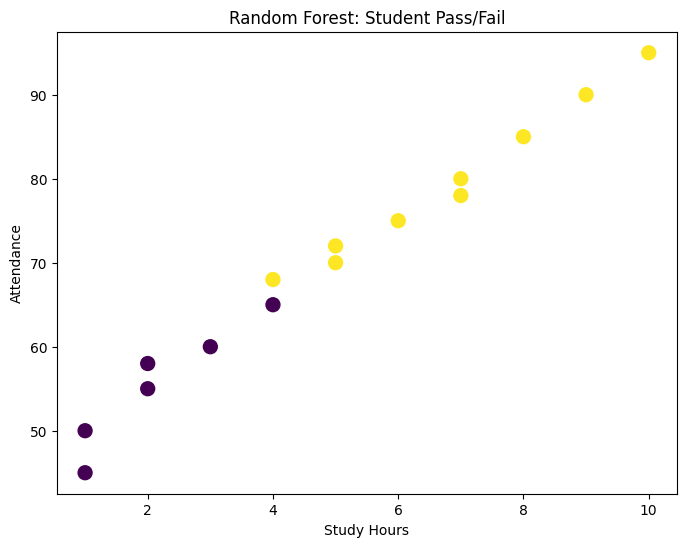

In [ ]:
# Random Forest Classification Predict Student Pass or Fail

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = {
    'Study_Hours': [1,2,3,4,5,6,7,8,2,5,7,9,10,1,4],
    'Attendance':  [50,55,60,65,70,75,80,85,58,72,78,90,95,45,68],
    'Pass':        [0,0,0,0,1,1,1,1,0,1,1,1,1,0,1]
}

df = pd.DataFrame(data)

print(df)


X = df[['Study_Hours', 'Attendance']]
y = df['Pass']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy =", accuracy)


new_student = [[6, 80]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nStudent will PASS")
else:
    print("\nStudent will FAIL")


plt.figure(figsize=(8,6))

# Scatter Plot
plt.scatter(
    df['Study_Hours'],
    df['Attendance'],
    c=df['Pass'],
    s=100
)

# Labels
plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Random Forest: Student Pass/Fail")

# Show Graph
plt.show()

Dataset:

    Study_Hours  Attendance  Pass
0             1          45     0
1             2          50     0
2             3          55     0
3             4          60     0
4             5          70     1
5             6          75     1
6             7          80     1
7             8          85     1
8             2          52     0
9             5          72     1
10            7          78     1
11            9          90     1
12           10          95     1
13            1          40     0
14            4          65     1
15            6          76     1
16            8          88     1
17            9          92     1

Accuracy: 1.0

Confusion Matrix:
[[3 0]
 [0 1]]

Prediction: Student will PASS


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


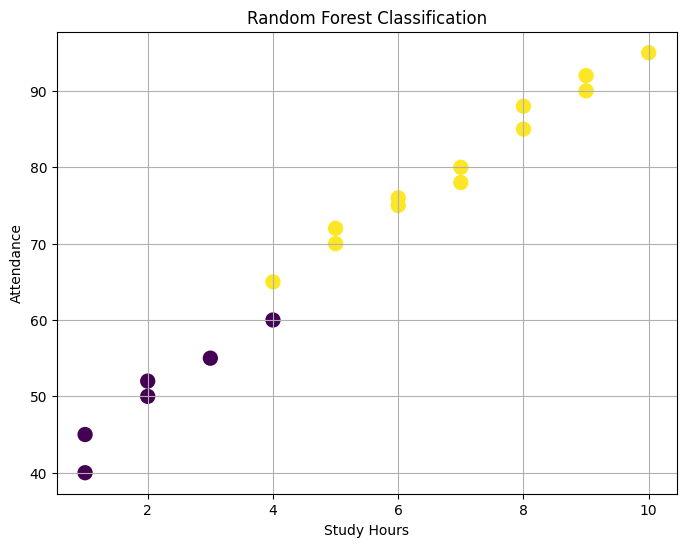

In [ ]:
# Random Forest Classifier Example Predict Student Pass or Fail

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

data = {
    'Study_Hours': [1,2,3,4,5,6,7,8,2,5,7,9,10,1,4,6,8,9],
    'Attendance':  [45,50,55,60,70,75,80,85,52,72,78,90,95,40,65,76,88,92],
    'Pass':        [0,0,0,0,1,1,1,1,0,1,1,1,1,0,1,1,1,1]
}
df = pd.DataFrame(data)

print("Dataset:\n")
print(df)

X = df[['Study_Hours', 'Attendance']]
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


new_student = [[6, 80]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nPrediction: Student will PASS")
else:
    print("\nPrediction: Student will FAIL")

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df['Study_Hours'],
    df['Attendance'],
    c=df['Pass'],
    s=100
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Random Forest Classification")

plt.grid(True)

plt.show()